In [69]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images
using Statistics

In [97]:
function load_crop_imgs(filenames, pathdir, x_crop, y_crop)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"])), x_crop, y_crop)
            img_bkg = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"])), x_crop, y_crop)
            img_dark = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"])), x_crop, y_crop)
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(intensities, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, intensities
end

function crop_img(img, x_crop, y_crop)
    return img[y_crop, x_crop]
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, sat, t_exp)
    ODs = zeros(size(imgs_atoms))
    for i in 1:size(imgs_atoms)[1]
        for j = 1:size(imgs_atoms)[2]
            OD = (imgs_atoms[i, j, :, :] .- imgs_dark[i, j, :, :]) ./ (imgs_bkg[i, j, :, :] .- imgs_dark[i, j, :, :])

            OD[OD .<= 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
            OD .= -log10.(OD)
            OD[isnan.(OD)] .= 0 # Map Nan values to 0
            OD[OD .== -Inf] .= 0 # Some values are send to -Inf

            # For high intensity, modified OD formula
            if sat[i] >= 1
                OD .+= (imgs_bkg[i, j, :, :] .- imgs_atoms[i, j, :, :]) / (7000*t_exp/5e-6)
            end
            ODs[i, j, :, :] .= OD
        end
    end
    return ODs
end

compute_OD_high_low_intensity (generic function with 2 methods)

In [71]:
pathdir = "Y:/TwoDGas/2026/01/19/0046"
Sat = [0.004, 0.4, 1.7, 4.7, 10, 16.5, 23, 28.5, 33, 37.5] # Estimated saturation parameter
I_set_value = [0.1:0.1:1;]
τ_exp = 5e-6 # In s
x_crop = [1100:1700;]
y_crop = [1750:2450;];

### Load and crop the images

In [72]:
if !isdir("Saved_exp_data")
    mkdir("Saved_exp_data")
end

In [73]:
files_path = readdir(pathdir)
Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Intensities = load_crop_imgs(files_path, pathdir, x_crop, y_crop);

### Reorganize the data per datasets

In [89]:
Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds = zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop)))

for i in 1:length(Imgs_atoms_crop)
        idx_line = findfirst(==(Intensities[i]), I_set_value)
        idx_row = floor(Int64, ((i-1)/(length(Sat))+1))
        Imgs_atoms_crop_ds[idx_line, idx_row, :, :] .= Imgs_atoms_crop[i]
        Imgs_bkg_crop_ds[idx_line, idx_row, :, :] .= Imgs_bkg_crop[i]
        Imgs_dark_crop_ds[idx_line, idx_row, :, :] .= Imgs_dark_crop[i]
end

In [90]:
@save "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds

### Compute the ODs

In [98]:
ODs_dataset = compute_OD_high_low_intensity(Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds, Sat, τ_exp);

In [99]:
@save "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

### Plot to check

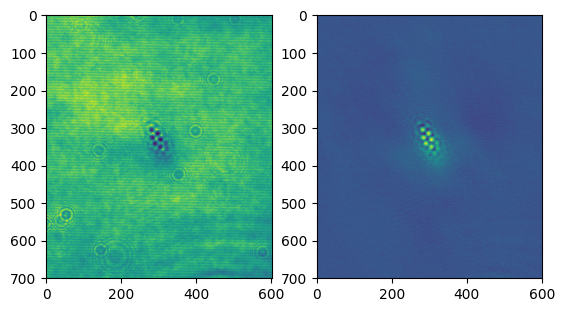

false

In [93]:
i, j = 10, 4

close("all")
fig, axs = subplots(1, 2)
axs[1].imshow(Imgs_atoms_crop_ds[i, j, :, :])
axs[2].imshow(ODs_dataset[i, j, :, :])
pygui(false)

# Save the ODs and negative ODs

In [94]:
if !isdir("Images")
    mkdir("Images")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
end

In [95]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="plasma") #, aspect="auto"
        cb = colorbar(img)
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                               ┫ 0/10 [00:00<00:00, -0s/it]
10.0%┣████▏                                     ┫ 1/10 [00:01<Inf:Inf, InfGs/it]
20.0%┣█████████▍                                     ┫ 2/10 [00:02<00:16, 2s/it]
30.0%┣██████████████                                 ┫ 3/10 [00:03<00:10, 1s/it]
40.0%┣██████████████████▉                            ┫ 4/10 [00:04<00:08, 1s/it]
50.0%┣███████████████████████▌                       ┫ 5/10 [00:05<00:06, 1s/it]
60.0%┣████████████████████████████▏                  ┫ 6/10 [00:06<00:05, 1s/it]
70.0%┣█████████████████████████████████              ┫ 7/10 [00:07<00:04, 1s/it]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:08<00:02, 1s/it]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:10<00:01, 1s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:11<00:00, 1s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:11<00:00, 1s/it]


In [96]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
        cb = colorbar(img)
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                               ┫ 0/10 [00:00<00:00, -0s/it]
10.0%┣████▏                                     ┫ 1/10 [00:02<Inf:Inf, InfGs/it]
20.0%┣█████████▍                                     ┫ 2/10 [00:03<00:22, 3s/it]
30.0%┣██████████████                                 ┫ 3/10 [00:04<00:14, 2s/it]
40.0%┣██████████████████▉                            ┫ 4/10 [00:05<00:11, 2s/it]
50.0%┣███████████████████████▌                       ┫ 5/10 [00:07<00:08, 2s/it]
60.0%┣████████████████████████████▏                  ┫ 6/10 [00:08<00:06, 2s/it]
70.0%┣█████████████████████████████████              ┫ 7/10 [00:09<00:05, 2s/it]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:10<00:03, 1s/it]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:12<00:01, 1s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:13<00:00, 1s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:13<00:00, 1s/it]
